# Car price — Random Forest
Data, model-name cleanup and train/val/test split come from `tree_data.py` = identical to `linear_regression.ipynb` sections 1–2.

- Features: engine_capacity, mileage, car_age + brand, model, fuel_type, gear_type, color (integer codes). No `OTHER_*` grouping — trees split on the cleaned model name directly.
- Target = `log(price)`; metrics on the price scale. No assumption tests (trees do not assume linearity / normal / constant-variance residuals).

In [1]:
import time, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import config as C
from tree_data import get_data, pick, tune_row, test_table, plot_test, importance, error_tables

pd.set_option("display.width", 200, "display.max_columns", 50)
train, val, test, X = get_data(codes=True)
y_log = np.log(train[C.TARGET])
print({k: len(v) for k, v in X.items()}, X['train'].shape)

removed 287 rows with car_age > 25


{'train': 20872, 'val': 4472, 'test': 4473} (20872, 8)


## 1. Tune on validation
Small grid; the test set is not touched here. `gap` = val MAE / train MAE (1 = no overfit).

Selection (`tree_data.pick`): among configs within 2% of the best val MAE, take the one with the smallest gap — near-best accuracy, least overfit. RF also reports out-of-bag MAE: a forest's train MAE is always far below val (each tree saw its own rows), OOB is the honest in-sample check.

In [2]:
rows, models = [], []
for p in [dict(max_features=f, min_samples_leaf=l) for f in [0.3, 0.5, 0.8] for l in [1, 3]]:
    m = RandomForestRegressor(n_estimators=500, **p, oob_score=True, n_jobs=-1, random_state=C.SEED)
    t = time.time(); m.fit(X['train'], y_log)
    r = tune_row(m, X, train, val, params=str(p), sec=round(time.time() - t, 1))
    r['oob_MAE'] = mean_absolute_error(train[C.TARGET], np.exp(m.oob_prediction_))
    rows.append(r); models.append(m)
tune = pd.DataFrame(rows).drop(columns='model')
tune.sort_values('MAE').round(4)

,RMSE,MAE,MAPE,R2,params,sec,train_MAE,gap,oob_MAE
4,205480.8992,73912.7088,0.1142,0.9092,"{'max_features': 0.8, 'min_samples_leaf': 1}",9.8,32971.8152,2.2417,84315.0986
2,212811.0641,74916.6069,0.1151,0.9026,"{'max_features': 0.5, 'min_samples_leaf': 1}",8.6,34024.1161,2.2019,86103.8195
5,227097.8014,79068.4264,0.1188,0.8891,"{'max_features': 0.8, 'min_samples_leaf': 3}",7.8,61851.3042,1.2784,89226.0422
0,244961.5660,79981.2190,0.1206,0.8710,"{'max_features': 0.3, 'min_samples_leaf': 1}",7.4,37827.0235,2.1144,93646.4206
3,239044.9332,81379.2368,0.1208,0.8772,"{'max_features': 0.5, 'min_samples_leaf': 3}",6.4,67834.4464,1.1997,92856.2156
1,297066.2053,92466.7250,0.1333,0.8103,"{'max_features': 0.3, 'min_samples_leaf': 3}",4.9,85040.7812,1.0873,106951.1910


## 2. Best params → evaluate test once

In [3]:
i = pick(tune); best = models[i]
pred_te, res = test_table('Random Forest', best, X, test, tune, i)
res

,RMSE,MAE,MAPE,R2,params,train_MAE,val_MAE,val_R2
model,,,,,,,,
Random Forest,178470.0794,73698.2554,0.1203,0.9181,"{'max_features': 0.5, 'min_samples_leaf': 1}",34024.1161,74916.6069,0.9026
MLR final (from LR notebook),192232.0000,85432.0000,0.1380,0.9050,NaN,NaN,NaN,NaN


## 3. Actual vs predicted (test, price scale)

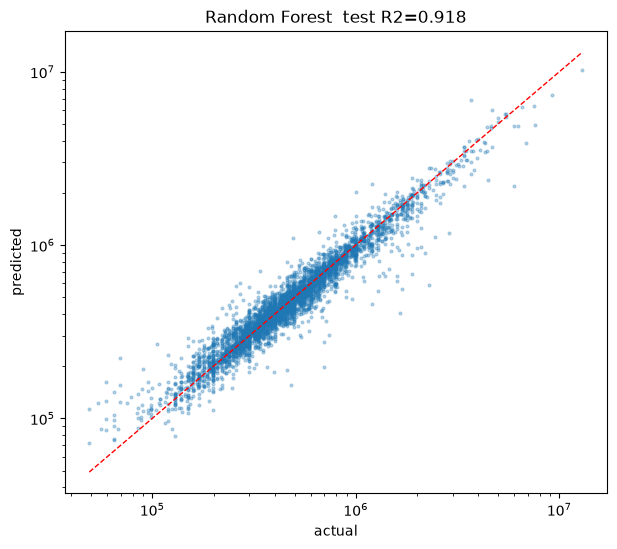

In [4]:
plot_test('Random Forest', test, pred_te)

## 4. Feature importance
Built-in (impurity/gain) importance is biased toward high-cardinality features (`model` ~490 levels), so permutation importance on validation is shown next to it.

In [5]:
importance(best, X, val)

,built-in,permutation (val)
engine_capacity,0.254,0.380
car_age,0.314,0.364
model,0.113,0.085
brand,0.089,0.070
fuel_type,0.077,0.042
mileage,0.088,0.029
gear_type,0.049,0.028
color,0.016,0.003


## 5. Where is the error? (validation, price scale)

In [6]:
by_age, by_model = error_tables(best, X, val)
display(by_age)
by_model

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",245,165725.985,0.104
"(2, 5]",1264,90398.997,0.099
"(5, 8]",1352,66043.971,0.105
"(8, 12]",964,63192.881,0.118
"(12, 16]",461,42788.488,0.154
"(16, 20]",126,57378.872,0.192
"(20, 25]",60,49920.831,0.217


n         MAE   MAPE  med_price
brand         model                                     
PORSCHE       CAYENNE   27  356060.285  0.140  2990000.0
MERCEDES-BENZ E300      19  222543.519  0.165  1259000.0
              C220      15  197582.763  0.147  1150000.0
              E220      10  192749.640  0.194  1009500.0
TOYOTA        ALPHARD   57  175641.529  0.105  1780000.0
HYUNDAI       STARIA    12  160350.077  0.118  1024500.0
MINI          COOPER    16  154000.211  0.161   496500.0
BMW           320D      11  149826.198  0.148   619000.0
              X5        13  149442.045  0.101  1860000.0
              330E      23  137965.772  0.147   998000.0
TOYOTA        VELLFIRE  50  134581.734  0.114  1344000.0
MERCEDES-BENZ C300      14  122194.380  0.128   879000.0
              C350      16  120825.607  0.178   569500.0
BMW           X3        12  118372.756  0.159   604000.0
FORD          EVEREST   71  110647.170  0.132   743000.0